### DATA 605 Assignment 1
#### Farhod Ibragimov

In [118]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.linalg import null_space

plt.rcParams['font.family'] = 'serif'          
plt.rcParams['font.size'] = 12


### Supply Chain Analytics with Vectors, Matrices, and Systems of Equations


A retail company operates three warehouses that distribute products to three sales regions. Management wants to evaluate current inventory levels, shipping patterns, and determine whether existing inventory can satisfy customer demand.

In [119]:
inventory_df = pd.read_csv(r'https://raw.githubusercontent.com/farhodibr/CUNY-SPS-MSDS/refs/heads/main/DATA605/Assignment1/data/inventory.csv', index_col='Warehouse')
inventory_df

,Region1,Region2,Region3
Warehouse,,,
A,1200,900,800
B,1000,1100,700
C,900,700,1000


In [120]:
demand_df = pd.read_csv(r'https://raw.githubusercontent.com/farhodibr/CUNY-SPS-MSDS/refs/heads/main/DATA605/Assignment1/data/demand.csv', index_col='Region')
demand_df

,Demand
Region,
Region1,2800
Region2,2400
Region3,2500


In [121]:
shipments_df = pd.read_csv(r'https://raw.githubusercontent.com/farhodibr/CUNY-SPS-MSDS/refs/heads/main/DATA605/Assignment1/data/shipments.csv', index_col='Warehouse')
shipments_df

,Region1,Region2,Region3
Warehouse,,,
A,300,400,500
B,400,350,250
C,500,300,200


In the cells below I will convert `inventory_df` and `shipments_df` to numpy matrices and `demand_df` into numpy array as vector.

In [122]:
inventory_matrix = inventory_df.to_numpy()
inventory_matrix

array([[1200,  900,  800],
       [1000, 1100,  700],
       [ 900,  700, 1000]])

In [123]:
demand_vector = demand_df['Demand'].to_numpy()
demand_vector

array([2800, 2400, 2500])

In [124]:
shipments_matrix = shipments_df.to_numpy()
shipments_matrix

array([[300, 400, 500],
       [400, 350, 250],
       [500, 300, 200]])

In [125]:
warehouses = ['A', 'B', 'C']
regions = ['Region 1', 'Region 2', 'Region 3']

### Part A: Inventory Analysis

Using vector operations:

1. Calculate total inventory available in each region.
2. Calculate inventory surplus or shortage relative to demand.
3. Identify which region is most at risk of stock shortages.
4. Interpret the business implications.

#### 1. Calculate total inventory available in each region.

Each row in `inventory_matrix` represent warehouse inventories for each region. For example first row `[1200,  900,  800]` represents Warehouse A's iventories for each region, and this vector represented as `inventory_matrix[0]`

To calculate total inventories per region I will perform vectors additions.
$$\vec{inventory}_{total} = \vec{iventory}_A + \vec{inventory}_B + \vec{inventory}_C$$

In [126]:
total_inventory = (
    inventory_matrix[0] + inventory_matrix[1]+ inventory_matrix[2]
)
total_inventory

array([3100, 2700, 2500])

In [127]:
for region, inventory in zip(regions, total_inventory):
    print(f"{region}'s inventory: {inventory} ")

Region 1's inventory: 3100 
Region 2's inventory: 2700 
Region 3's inventory: 2500 


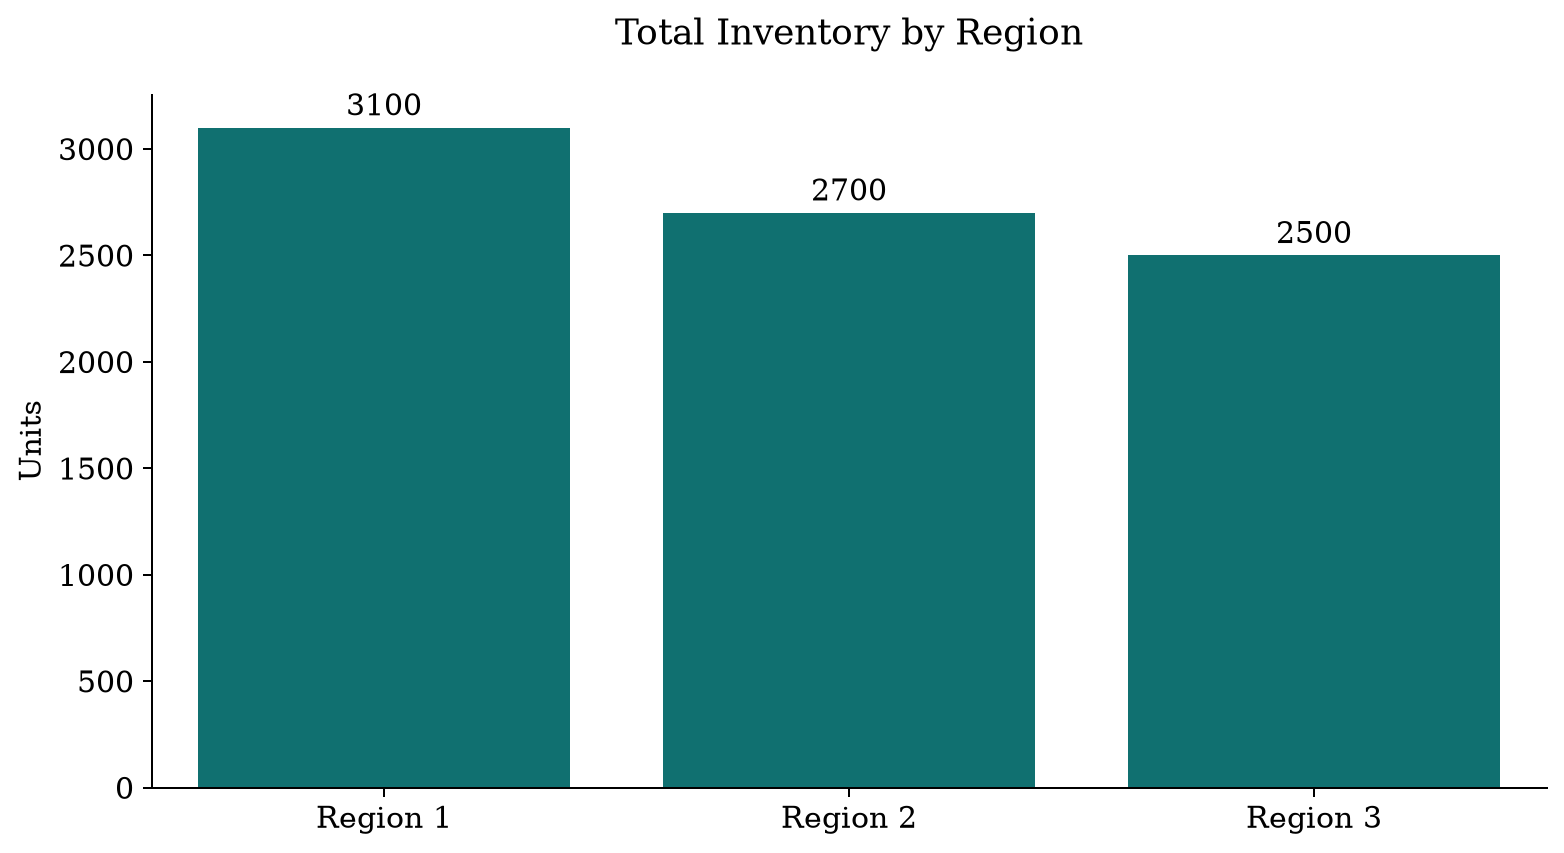

In [128]:
total_df = pd.DataFrame({'Region': regions, 'Total Inventory': total_inventory, 'Demand': demand_vector})

plt.figure(figsize=(10, 5), dpi=180)
ax = sns.barplot(data=total_df, x='Region', y='Total Inventory', color='teal')

for container in ax.containers:
    ax.bar_label(container, padding=2)
plt.title('Total Inventory by Region', pad=20,)
plt.ylabel('Units')
plt.xlabel('')
sns.despine()
plt.show()

#### 2. Calculate inventory surplus or shortage relative to demand.

To calculate surplus/shortage I will use vector subtraction:
$$\vec{surplus} = \vec{inventory}_{total} - \vec{demand}$$



In [129]:
surplus = total_inventory - demand_vector

print(f"{'Region':<10}{'Inventory':>12}{'Demand':>10}{'Surplus':>10}")
for r, inv, dem, sur in zip(regions, total_inventory, demand_vector, surplus):
    print(f"{r:<10}{inv:>12}{dem:>10}{sur:>10}")

Region       Inventory    Demand   Surplus
Region 1          3100      2800       300
Region 2          2700      2400       300
Region 3          2500      2500         0


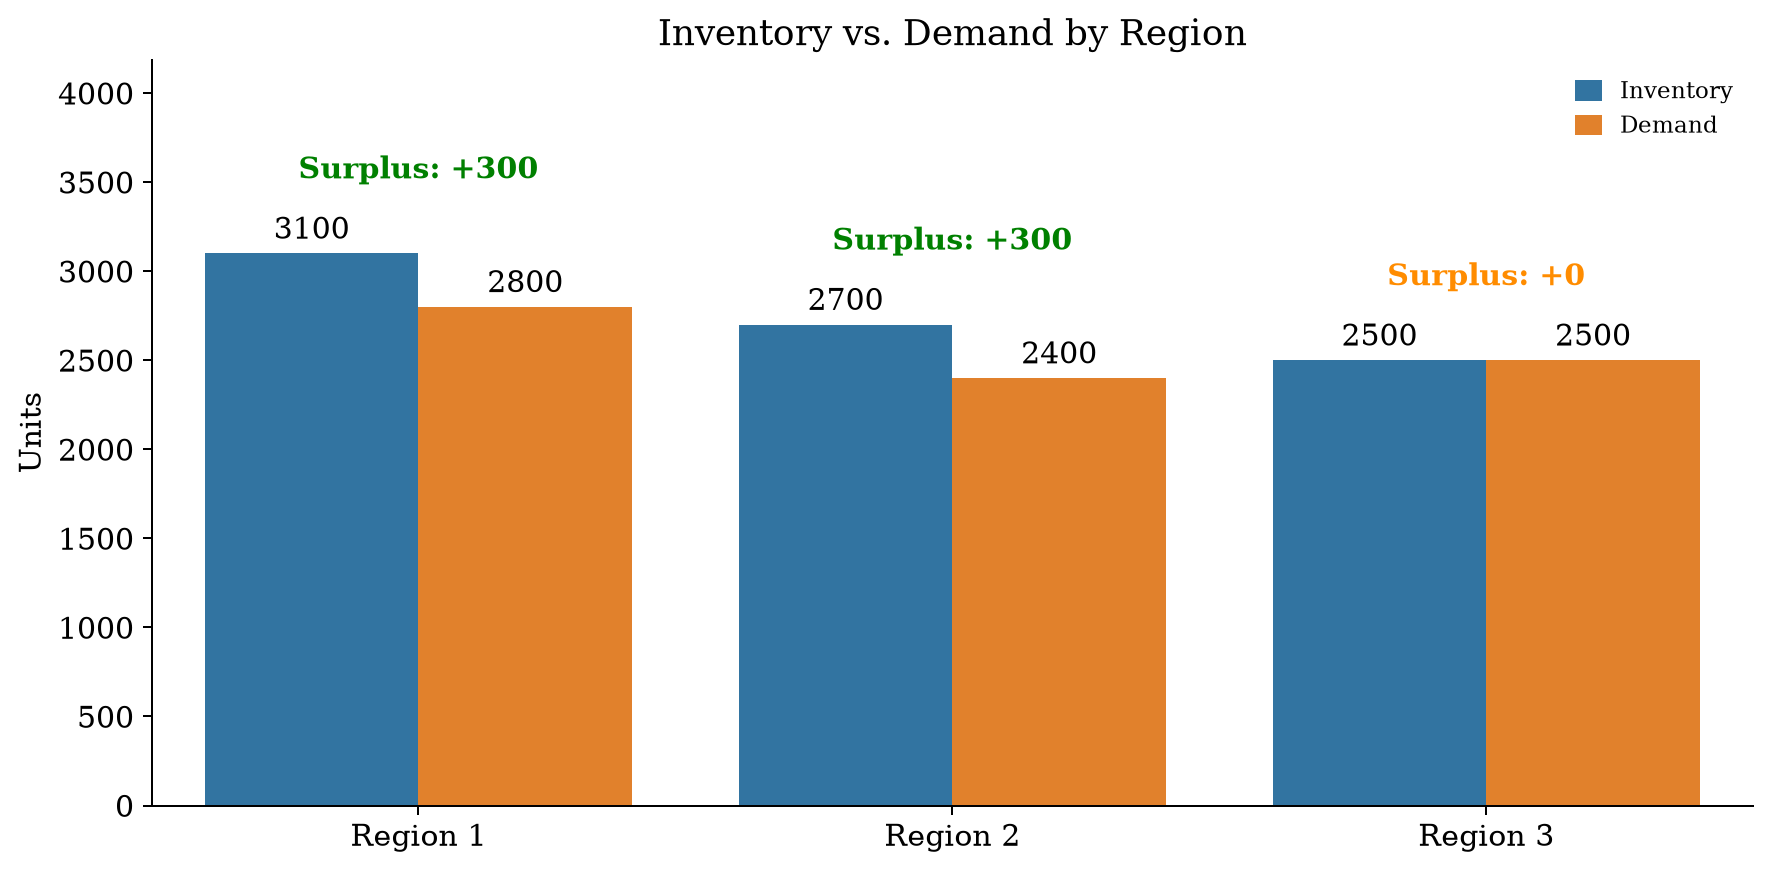

In [130]:
plot_df = pd.DataFrame({
    'Region': regions,
    'Inventory': total_inventory,
    'Demand': demand_vector
})
plot_long = plot_df.melt(id_vars='Region', value_vars=['Inventory', 'Demand'],
                          var_name='Metric', value_name='Units')

plt.figure(figsize=(10, 5), dpi=180)
ax = sns.barplot(data=plot_long, x='Region', y='Units', hue='Metric')

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)

for i, (region, sur) in enumerate(zip(regions, surplus)):
    max_height = max(total_inventory[i], demand_vector[i])
    label = f'Surplus: {sur:+.0f}'
    color = 'green' if sur > 0 else ('crimson' if sur < 0 else 'darkorange')
    ax.annotate(label, xy=(i, max_height), xytext=(0, 30),
                textcoords='offset points', ha='center',
                fontsize=12, fontweight='bold', color=color)

ax.set_title('Inventory vs. Demand by Region')
ax.margins(y=0.35)  
sns.despine()

ax.legend(
    loc='upper right',
    frameon=False,
    fontsize=9,
    title=None,
    handlelength=1.2,
    handleheight=1.0
)
plt.xlabel('')
plt.tight_layout()
plt.show()

#### 3. Identify which region is most at risk of stock shortages.

To identify the region that at highest risk of stock shortage I will take a look at proportion ratios of each region's stock surpluse to its regional demand.

In [131]:
prop_ratio = (surplus / demand_vector) * 100
prop_ratio

array([10.71428571, 12.5       ,  0.        ])

In [132]:
lowest_surplus = np.argmin(surplus)

for region, prop in zip(regions, prop_ratio):

    if prop != prop_ratio.min():
        print(f"{region}'s surplus to demand ratio: {prop.round(2)}%")
    else:
        print(f"\n{region}'s surplus to demand ratio: {prop.round(2)}%."
              f"\nIt has highest risk of stock shortage with surplus of {surplus[lowest_surplus]}")

Region 1's surplus to demand ratio: 10.71%
Region 2's surplus to demand ratio: 12.5%

Region 3's surplus to demand ratio: 0.0%.
It has highest risk of stock shortage with surplus of 0


#### 4. Interpret the business implications.

As we see from results:
- Regions 1 and 2 each have same surplus of 300 units, but their overstock's can cover 10.7% and 12.5% of demand in case of spikes or supply shortages. 
- Region 3 is at the most risk of stock shortage with surplus of 0. Any rise of product's demand or delayed shipments to warehouses can cause disruption of supply in this situations.

I think better ways to manage this risk:
- relocate some surplus stocks to Region 3
- or deliver more product to warehouses to increase Region 3's surplus (this depends on warehouse and transportation capacities)

## Part B: Shipment Matrix Analysis

Using matrix operations:

1. Create a shipment matrix from the data.



In [133]:
shipments_matrix

array([[300, 400, 500],
       [400, 350, 250],
       [500, 300, 200]])


The shipment matrix $S$ has one row vector per warehouse (sto to all 3 regions) and
one column vector per region (what it received from all 3 warehouses):

$$S = \begin{bmatrix} 300 & 400 & 500 \\ 400 & 350 & 250 \\ 500 & 300 & 200 \end{bmatrix}
\begin{matrix}\leftarrow Warehouse A \\ \leftarrow Warehouse B \\ \leftarrow Warehouse C\end{matrix}$$

#### 2. Compute row totals and column totals.



To get warehouse totals (row totals) and region totals (column totals), I use vector
operations instead of just calling `.sum()`.

*Row totals (per warehouse):*

I create a `ones_vector` the same length as one row of the shipments matrix. Then, for each
warehouse row in `shipments_matrix`, I take the dot product of that row with `ones_vector`.
Since dotting any vector with a vector of all 1s just adds up its entries, this gives me the
total shipped by that warehouse:

$$\text{row total} = \vec{row} \cdot \vec{1} = row_1(1) + row_2(1) + row_3(1)$$

I loop through each row, compute its dot product with `ones_vector`, and append the result to
`warehouses_totals`, then convert the list back into a NumPy array so it's consistent with the
rest of the matrix operations.

*Column totals (per region):*

For column totals, I add the three warehouse row-vectors together directly:

$$\vec{region\_totals} = \vec{shipments\_matrix[0]} + \vec{shipments\_matrix[1]} + \vec{shipments\_matrix[2]}$$

This is plain vector addition - each entry of the result is the sum of that region's shipments
across all three warehouses, since I'm adding the rows entry-by-entry rather than dotting them
with anything.

In [134]:
ones_vector = np.ones_like(shipments_matrix[0])

warehouses_totals = []
for row, region, warehouse in zip(range(0, len(shipments_matrix)), regions, warehouses):
    #print(shipments_matrix[row])
    warehouse_total = np.dot(shipments_matrix[row], ones_vector)
    warehouses_totals.append(warehouse_total)

warehouses_totals = np.array(warehouses_totals)

regions_totals = (
    shipments_matrix[0]+
    shipments_matrix[1]+
    shipments_matrix[2]
    )
print(f"Row totals: {warehouses_totals}")
print(f"Column totals {regions_totals}")

Row totals: [1200 1000 1000]
Column totals [1200 1050  950]


#### 3. Determine which warehouse ships the most products.

In [135]:
for warehouse, total in zip(warehouses, warehouses_totals):
    print(f"Warehouse {warehouse}'s total shipment to regions: {total}")

print(" ")



Warehouse A's total shipment to regions: 1200
Warehouse B's total shipment to regions: 1000
Warehouse C's total shipment to regions: 1000
 


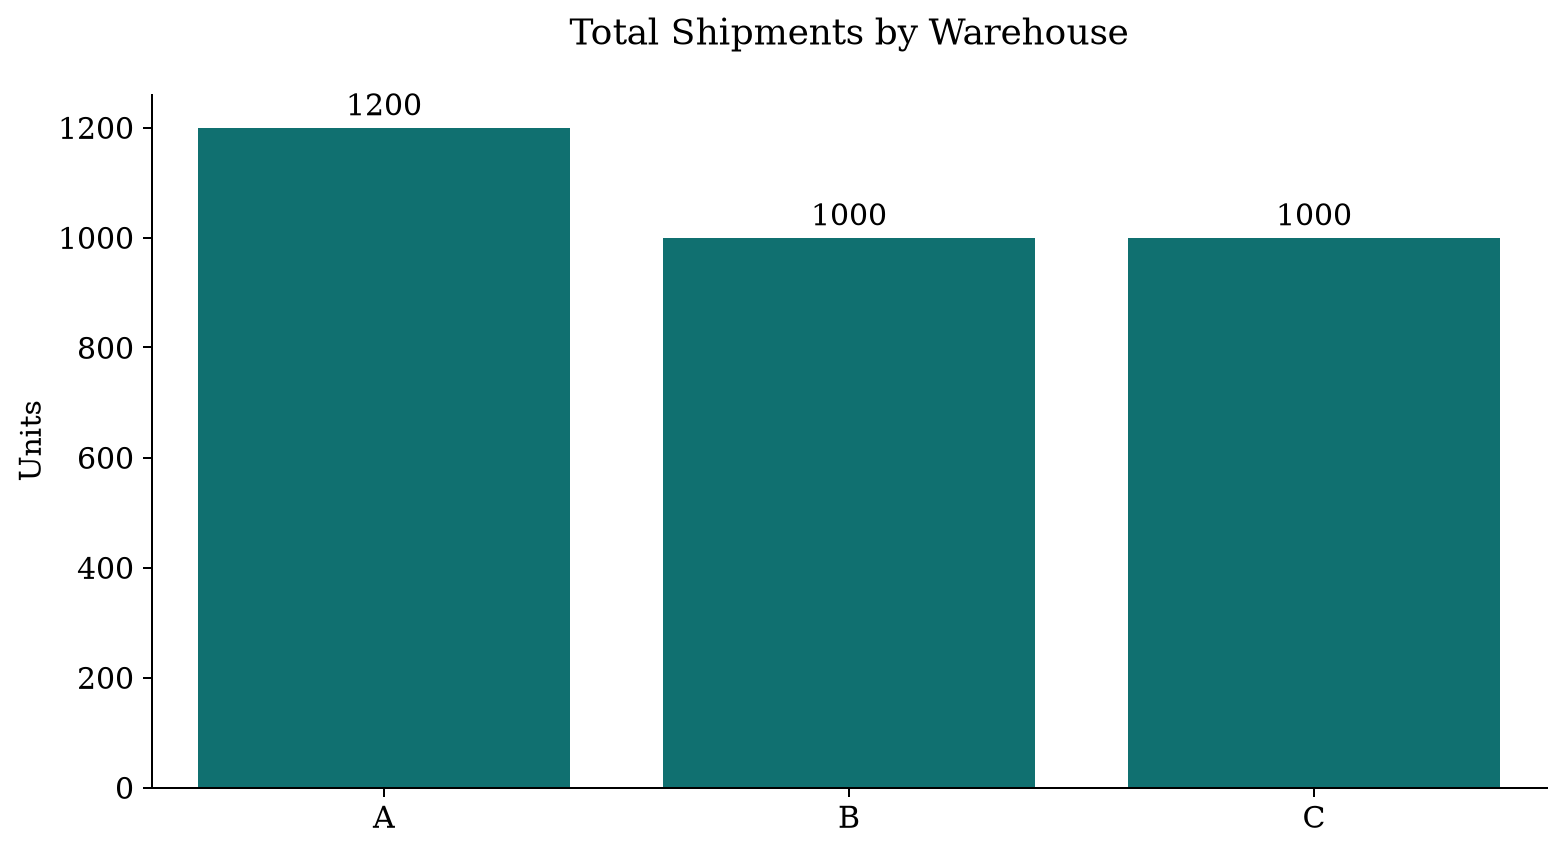

In [136]:
total_df = pd.DataFrame({'Warehouse': warehouses, 'Total shipments': warehouses_totals, 'Demand': demand_vector})

plt.figure(figsize=(10, 5), dpi=180)
ax = sns.barplot(data=total_df, x='Warehouse', y='Total shipments', color='teal')

for container in ax.containers:
    ax.bar_label(container, padding=2)
plt.title('Total Shipments by Warehouse', pad=20,)
plt.ylabel('Units')
plt.xlabel('')
sns.despine()
plt.show()

Using vector operations I calculated total shipments by each Warehouse to regions:
- Warehouse A shipped 1200 units
- Warehouses B and C each shipped 1000 units

From results and the plot Warehouse A ships highest amount of items. 


#### 4. Determine which region receives the most products.

In [137]:
regions_totals = (shipments_matrix[0]+
                          shipments_matrix[1]+
                           shipments_matrix[2] )

regions_totals = np.array(regions_totals)

In [138]:
print(regions_totals)
for region, region_total in zip(regions, regions_totals):
    print(f"{region} received total: {region_total}")

[1200 1050  950]
Region 1 received total: 1200
Region 2 received total: 1050
Region 3 received total: 950


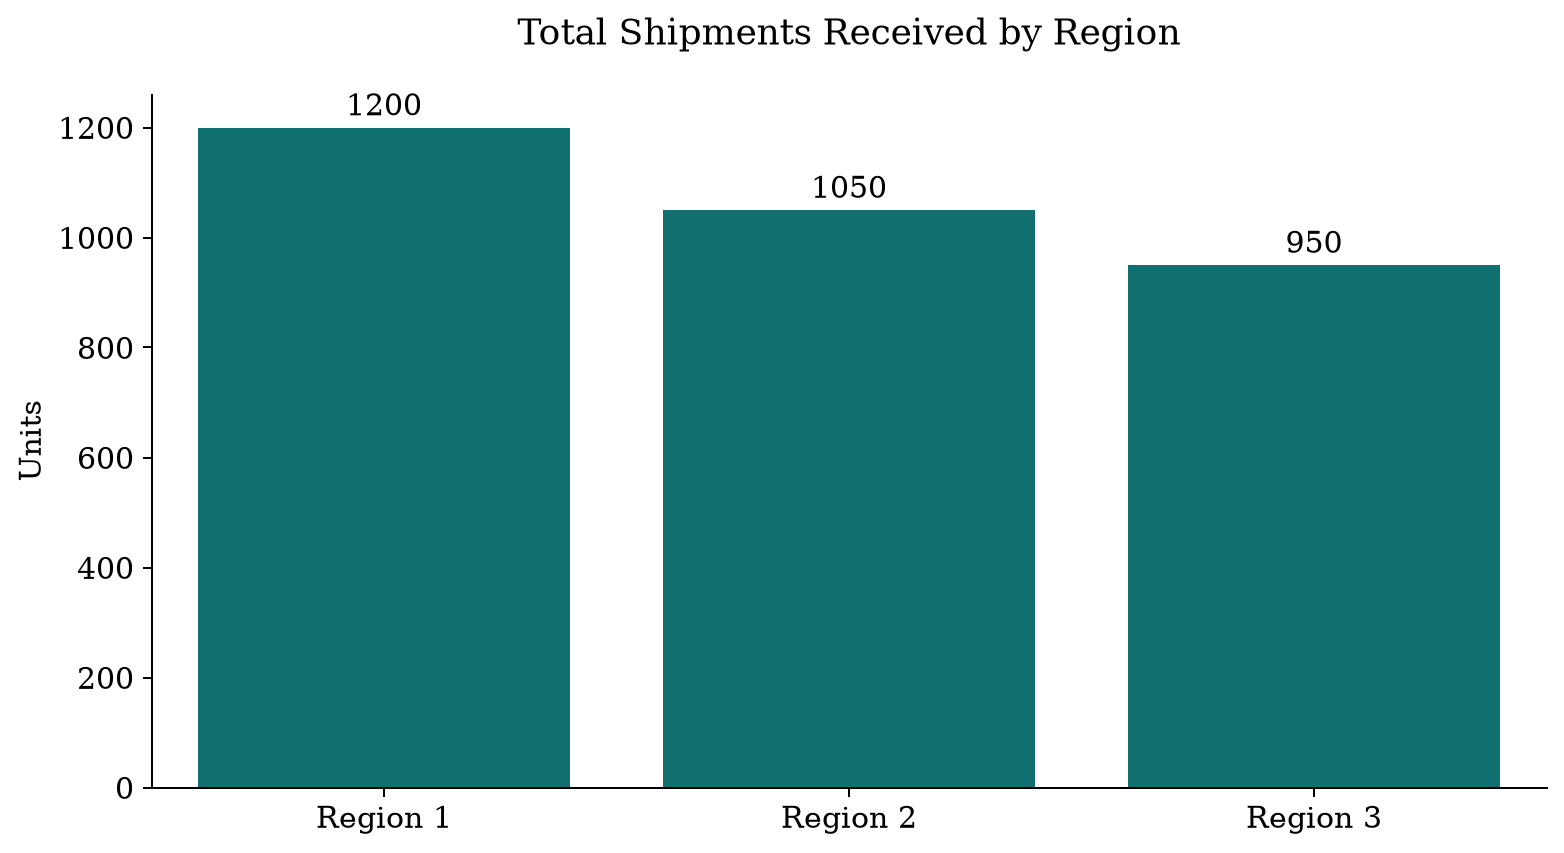

In [139]:

total_df = pd.DataFrame({'Region': regions, 'Total Received': regions_totals, 'Demand': demand_vector})

plt.figure(figsize=(10, 5), dpi=180)
ax = sns.barplot(data=total_df, x='Region', y='Total Received', color='teal')

for container in ax.containers:
    ax.bar_label(container, padding=2)
plt.title('Total Shipments Received by Region', pad=20,)
plt.ylabel('Units')
plt.xlabel('')
sns.despine()
plt.show()

As we see from the plot:
- Region 1 received total 1200 items
- Region 2 received total 1050 items
- Region 3 received total 95 items

Therefore, Region 1 received most items while Region 3 received the fewest shipments.



In [140]:
basis = np.array(
    [[3, 0],
    [0, 2]]
)

v = np.array([1,1])

new_v = np.dot(basis,v)
print(new_v)

[3 2]


In [141]:
i_hat = np.array([2, 3])
j_hat = np.array([2, -1])

basis = np.array([i_hat, j_hat]).transpose()
basis

v = np.array([2,1])
new_v = np.dot(basis, v)
new_v

array([6, 5])

## Part C: Resource Allocation Model (Systems of Linear Equations)



After reviewing inventory levels and shipment activity, management wants to determine how many additional truckloads of inventory should be sent from each warehouse next week to meet projected demand.

Let:

* $x$ = number of truckloads shipped from Warehouse A
* $y$ = number of truckloads shipped from Warehouse B
* $z$ = number of truckloads shipped from Warehouse C

Based on transportation capacity and regional replenishment requirements, management has developed the following system of equations:

$$x + y + z = 18 \quad \text{(Total truckloads available for shipment)}$$
$$2x + y = 26 \quad \text{(Capacity constraints at Warehouse A)}$$
$$y + 2z = 22 \quad \text{(Combined delivery requirements for Warehouses B and C)}$$

#### 1. Express the system in matrix form

From the system of linear equations each equation becomes one row. Missing variables just get a coefficient of 0, and we get $Ax = b$:

$$\underbrace{\begin{bmatrix} 1 & 1 & 1 \\ 2 & 1 & 0 \\ 0 & 1 & 2 \end{bmatrix}}_{A}
\underbrace{\begin{bmatrix} x \\ y \\ z \end{bmatrix}}_{x} =
\underbrace{\begin{bmatrix} 18 \\ 26 \\ 22 \end{bmatrix}}_{b}$$

where:
- $A$ is coefficients matrix 
- $b$ is constants vector

In [142]:
A = np.array([
    [1,1,1],
    [2,1,0],
    [0,1,2],
], dtype=float
)

b= np.array([18, 26, 22], dtype=float)

print('Coefficient matrix A:')
display(A)
print('')
print('Constant vector:')
display(b)

Coefficient matrix A:


array([[1., 1., 1.],
       [2., 1., 0.],
       [0., 1., 2.]])


Constant vector:


array([18., 26., 22.])

### 2. Solve the system computationally

Before solving, I will check the determinant. If it's zero, $A$ is
a singular (not invertible) matrix, which means there is not a unique solution. This isn't just a
formality here, it matters to find out if there are solutions for this matrix.

In [143]:
det_A = np.linalg.det(A)
print(f"det(A) = {det_A}")

det(A) = 0.0


The result shows `det(A) = 0`, so this system does not have unique solution. Let's check *why*: `det(A) = 0` usually means the rows of $A$ are not linearly independent, therefore one
row can be built from the others by linear transformation. Let's confirm that with rank test:  if the
augmented matrix $[A \mid b]$ has a higher rank than $A$ alone, the system has no solution.

In [144]:
rank_A = np.linalg.matrix_rank(A)
augmented = np.column_stack([A, b])
rank_Ab = np.linalg.matrix_rank(augmented)

print(f"rank(A)      = {rank_A}")
print(f"rank([A|b])  = {rank_Ab}")

rank(A)      = 2
rank([A|b])  = 3


Rank test confirms that there is no uniques solution for company's linear equations. Augmented matrix $[A \mid b]$ has a *higher* rank = 3 than $A$'s rank=2.

Determinant equals 0 says that coefficient matrix $A$ is singular and that one of the rows can be built out of ohter rows (e.g one of the rows is linearly dependent).

Below I will find out which of the rows is linearly dependant:

In [145]:
n_rows = A.shape[0]

for row in range(n_rows):
    other_rows = [j for j in range(n_rows) if j != row]
    B = A[other_rows].T
    target = A[row]

    coeffs, residuals, rank, sv = np.linalg.lstsq(B, target, rcond=None)
    reconstructed = B @ coeffs
    error = np.linalg.norm(reconstructed - target)

    print(f"Row {row}: {coeffs[0]:.2f} * Row{other_rows[0]} + {coeffs[1]:.2f} * Row{other_rows[1]}")
    print(f"        reconstruction error = {error:.6f}\n")

Row 0: 0.50 * Row1 + 0.50 * Row2
        reconstruction error = 0.000000

Row 1: 2.00 * Row0 + -1.00 * Row2
        reconstruction error = 0.000000

Row 2: 2.00 * Row0 + -1.00 * Row1
        reconstruction error = 0.000000



I looped through each row and tried to reconstruct it using the other two rows (least squares), to see which row(s) are linearly dependent.

- Row 0: 0.50 * Row1 + 0.50 * Row2
- Row 1: 2.00 * Row0 + -1.00 * Row2
- Row 2: 2.00 * Row0 + -1.00 * Row1

All three rows reconstruct with 0 error, not just one. This makes sense given rank(A) = 2, since all three rows are located in the same 2D plane, any one row can be written as a combination of the other two, not just a single "odd one out."

The cleanest version of this relationship (whole number coefficients) is Row2's:

$$2 \times Row_0 - Row_1 = Row_2$$

I'll use this version going forward since it's easiest to check against the constants vector $b$.

In [146]:
combined_coeffs = 2*A[0] - A[1]
combined_rhs = 2*b[0] - b[1]

print(f"2*Row1 - Row2 produces:  {combined_coeffs[0]:.0f}x + {combined_coeffs[1]:.0f}y + {combined_coeffs[2]:.0f}z = {combined_rhs}")
print(f"Row3 actuall:    {A[2][0]:.0f}x + {A[2][1]:.0f}y + {A[2][2]:.0f}z = {b[2]}")

2*Row1 - Row2 produces:  0x + 1y + 2z = 10.0
Row3 actuall:    0x + 1y + 2z = 22.0


As we see by using matrix operation $$2 \times Row_0 - Row_1 = Row_2$$ 

that produces new equation $$0x + 1y + 2z = 10$$ 

but the real 3rd equation is $$0x + 1y + 2z = 22$$

We see that left sides are equal, but constants are different:

$$y + 2z = 10 \quad \text{vs.} \quad y + 2z = 22$$

This means the third equation contradicts what the first two equations already imply. There is no solutions $(x, y, z)$ that can make $y + 2z$ equal to both 10 and 22 at the same time, so the system has no solution.



Therefore it is proven algebraically that the system is inconsistent. Transforming it back into the business problem: adding Equations 2 and 3 together gives $$(2x+y) + (y+2z) = 26+22=48$$ and the left side simplifies to $$2(x+y+z) = 48.$$ So if simplify this we will get  $$x+y+z=24$$  but this cotradicts to Equation 1 trucloads caps the total at only 18.

In [147]:
implied_total = (b[1] + b[2]) / 2   
print(f"Eq2 + Eq3:  x+y+z = {implied_total}")
print(f"Actual Eq1 states x+y+z = {b[0]}")
print(f"Truckloads shortage: {implied_total - b[0]} truckloads")

Eq2 + Eq3:  x+y+z = 24.0
Actual Eq1 states x+y+z = 18.0
Truckloads shortage: 6.0 truckloads


As we see we have shortfall of total 6 truckloads to satisfy given linear equations

### How could this be solved?

Since the system is inconsistent, there is no single correct solution without more information from company's management. But I would propose a few options that would resolve the issue:

1. Increase the total truckload cap in Equation 1 from 18 to 24 if possible, matching what Equations 2 and 3 actually require. This is the right fix if 18 was an assumed estimate rather than a restricted trucloads limit.
2. Scale back one of the individual requirements (Equation 2 or 3) so all three equations agree on a total of 18. This is the right fix if 18 is a strict constraint (e.g. actual available truckloads) and the regional requirements need to be recalculated.
3. Discuss these issues with management to get updated numbers rather than guessing which of the three equations is mistaken, only company's management can say which constraint is flexible and which is fixed.

This connects directly to what we already found in Part A: Region3 has a surplus of exactly **0**, meaning it has no backup to handle any spikes of demand or disruptions of shipments, while Region1 and Region2 both carry a 300-unit surpluses each. If this 6-truckload difference has to be distributed, Region3's supply chain is the one with no room to give, therefore it becomes main priority when management review these constraints.

In [148]:
bc_combined = shipments_matrix[1] + shipments_matrix[2]
bc_total = bc_combined.sum()

print("Warehouses B+C combined shipments by region:", bc_combined)
print(f"Share going to Region3: {bc_combined[2]/bc_total*100:.1f}%")

Warehouses B+C combined shipments by region: [900 650 450]
Share going to Region3: 22.5%


Between the two numeric options above, findings in Part A and B favors raising the capacity of trckloads from 18 to 24 (Option 1) over cutting the B&C requirement (Option 2).

Equation 3 represents the combined delivery requirement for Warehouses B and C. Looking at Part B's shipment matrix, B and C together send 22.5% of their combined shipments to Region3. Region3 is also the one region Part A flagged with a surplus of exactly $0$, meaning it has no extra stocks to handle a shortfall.

With that, reducing the B&C requirement to resolve the conflict would directly cut into the shipments most responsible for keeping the one already shacky region stocked. On the other hand, raising the total truckload cap from 18 to 24 avoids that trade-off entirely, it doesn't reduce any warehouse's contribution, it simply acknowledges that meeting all three original requirements needs more trucloads capacity than given 18 trucks provided. Between the two,  raising the total truckload cap is the one that doesn't risk worsening Region3's already-thin surplus margin.

### Solving equations with the total capacity of 24 instead of 18

Changing only Equation 1's constant from 18 to 24 trucloads makes the system consistent, but the coefficient matrix `A` is still remains singular (unchanged from the original), therefore this will not produce one unique answer. It will give infinitely many solutions, forming a line of solutions rather than a single point.

Below are calculations with updated Euation 1's contant of 24 instead of 18



In [149]:
b_opt1 = np.array([24, 26, 22], dtype=float)

particular, residuals, rank, sv = np.linalg.lstsq(A, b_opt1, rcond=None)
print("minimum-norm solution:", particular)

check = A @ particular
print("A @ x =", check)
print("b     =", b_opt1)


minimum-norm solution: [9. 8. 7.]
A @ x = [24. 26. 22.]
b     = [24. 26. 22.]


In [150]:


ns = null_space(A)
print("Null space vector:")
print(ns)

Null space vector:
[[-0.40824829]
 [ 0.81649658]
 [-0.40824829]]




`null_space(A)` returns a matrix whose columns are basis vectors for the null space: the set of vectors $v$ satisfying $$Av = 0$$. As we saw earlier `A` is 3×3 matrix with rank 2, the nullity (dimension of the null space) is $$3 - 2 = 1,$$ so the result is a single column: exactly one independent direction.

By convention, `scipy` normalizes this vector to have length 1:

$$\|(-0.408,\ 0.816,\ -0.408)\| = 1$$

This is a mathematically valid basis vector, but the decimal values obscure a cleaner underlying ratio. Dividing every component by the smallest one (in absolute value) we get:

$$\frac{(-0.408,\ 0.816,\ -0.408)}{0.408} = (-1,\ 2,\ -1)$$

Since the null space is a line through the origin of the vector's, any nonzero scalar multiple of a null space vector points in the same direction and satisfies $$Av=0$$ equally well: $$(-0.408, 0.816, -0.408), (-1,2,-1), and (1,-2,1)$$  all represent the identical solution direction. I will use $(1,-2,1)$ for simplicity because whole numbers are easier to read in a table; flipping the sign only reverses which direction increasing $s$ moves along the line, not the set of solutions itself.

In [151]:
direction = np.array([1., -2., 1.])

s_values = np.arange(-7, 5)
solutions = particular + s_values[:, None] * direction

solutions_df = pd.DataFrame(np.round(solutions).astype(int), columns=['x', 'y', 'z'])
solutions_df.insert(0, 's', s_values)
solutions_df

,s,x,y,z
0,-7,2,22,0
1,-6,3,20,1
2,-5,4,18,2
3,-4,5,16,3
4,-3,6,14,4
5,-2,7,12,5
6,-1,8,10,6
7,0,9,8,7
8,1,10,6,8
9,2,11,4,9


Using the null space of `A`, the complete solution set with the assumed 24 truckloads (instead of 18) is:

$$\begin{bmatrix}x\\y\\z\end{bmatrix} = \begin{bmatrix}9\\8\\7\end{bmatrix} + s\begin{bmatrix}1\\-2\\1\end{bmatrix},$$

where:
- $s$ is a free parameter any real number ($s \in \mathbb{R}$)

Requiring non-negative truckload counts restricts `s` to roughly `[-7, 4]`, giving 12 valid whole-number allocations, ranging from `(2, 22, 0)` to `(13, 0, 11)`. The `s=0` case, `(x=9, y=8, z=7)`, is the minimum-norm solution, and this is most evenly balanced truckload allocation among all valid options, and the one `np.linalg.lstsq` returns by default.

**Note:** these are solutions to a *modified* system (in Equation 1 I raised total available truckloads from 18 to 24), not for the original equations as management gave them. As we saw previously there is no exact solution to the original system exists. I calculated this modified system to show that if the total truckload capacity could possibly be increased to 24, then all three original requirements could be satisfied exactly, without needing to remove the combined B & C requirement that helps protect Region3's already thin supply inventory.